# K-Means en Python: Ejemplo completo, parámetros y visualizaciones

## Objetivo de la notebook

- Generar un dataset sintético relacionado con gustos de películas.
- Explorar visualmente los datos.
- Aplicar K-Means.
- Entender cómo elegir el valor de k.
- Explicar parámetros importantes.
- Visualizar clusters y centroides.
- Visualizar fronteras aproximadas.
- Realizar nuevas predicciones.


## 1. Introducción teórica

K-Means es un algoritmo de aprendizaje no supervisado utilizado para agrupar datos similares.

El objetivo es dividir los datos en k clusters.

Cada cluster posee un centro llamado centroide.

## 2. Importación de librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## 3. Generación del dataset sintético

Vamos a simular usuarios de una plataforma de streaming.

In [2]:

np.random.seed(42)

accion = np.random.normal(loc=80, scale=10, size=100)
romance = np.random.normal(loc=20, scale=8, size=100)
scifi = np.random.normal(loc=70, scale=10, size=100)
horas = np.random.normal(loc=25, scale=5, size=100)
puntaje = np.random.normal(loc=8, scale=0.7, size=100)

accion2 = np.random.normal(loc=25, scale=10, size=100)
romance2 = np.random.normal(loc=85, scale=10, size=100)
scifi2 = np.random.normal(loc=30, scale=10, size=100)
horas2 = np.random.normal(loc=18, scale=5, size=100)
puntaje2 = np.random.normal(loc=7, scale=0.8, size=100)

accion3 = np.random.normal(loc=50, scale=10, size=100)
romance3 = np.random.normal(loc=45, scale=10, size=100)
scifi3 = np.random.normal(loc=90, scale=8, size=100)
horas3 = np.random.normal(loc=30, scale=5, size=100)
puntaje3 = np.random.normal(loc=9, scale=0.5, size=100)

movies_df = pd.DataFrame({
    'accion': np.concatenate([accion, accion2, accion3]),
    'romance': np.concatenate([romance, romance2, romance3]),
    'scifi': np.concatenate([scifi, scifi2, scifi3]),
    'horas_streaming': np.concatenate([horas, horas2, horas3]),
    'puntaje_promedio': np.concatenate([puntaje, puntaje2, puntaje3])
})

movies_df.head()


,accion,romance,scifi,horas_streaming,puntaje_promedio
0,84.967142,8.677034,73.577874,20.855025,6.883901
1,78.617357,16.634837,75.607845,22.199095,7.580437
2,86.476885,17.258284,80.830512,28.736468,8.003671
3,95.230299,13.581782,80.538021,28.051851,8.032886
4,77.658466,18.709714,56.223306,24.895492,7.684954


## 4. Exploración inicial del dataset

In [3]:

movies_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   accion            300 non-null    float64
 1   romance           300 non-null    float64
 2   scifi             300 non-null    float64
 3   horas_streaming   300 non-null    float64
 4   puntaje_promedio  300 non-null    float64
dtypes: float64(5)
memory usage: 11.8 KB


In [4]:

movies_df.describe()


,accion,romance,scifi,horas_streaming,puntaje_promedio
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,51.470074,50.496764,63.650868,24.834304,8.038428
std,24.360164,28.555218,26.958873,6.397771,1.101516
min,0.283555,4.649830,9.180706,10.421279,5.060897
25%,29.954328,23.790182,36.181505,20.512278,7.198390
50%,51.977552,46.904966,70.976957,25.103770,8.058740
75%,73.985604,78.219502,85.976154,29.306624,8.934625
max,98.522782,110.733598,110.637675,40.786541,10.300842


## 5. Visualización de los datos

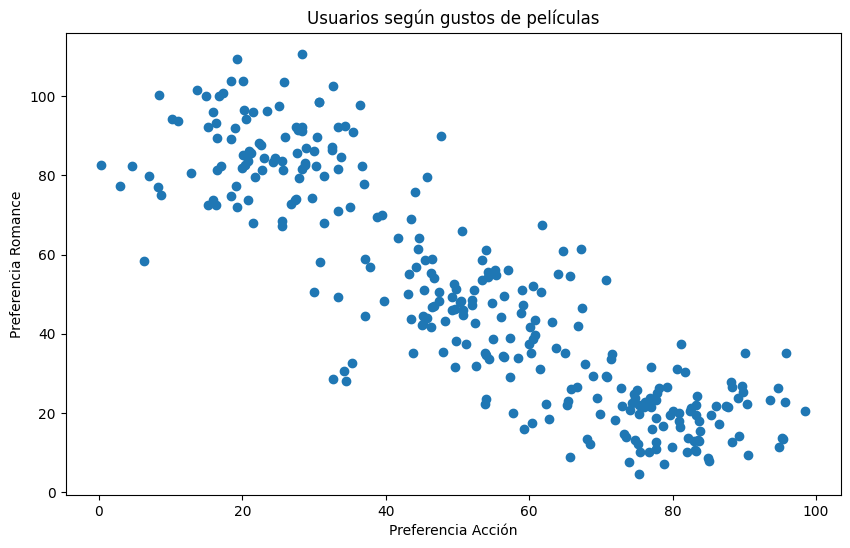

In [5]:

plt.figure(figsize=(10,6))

plt.scatter(
    movies_df['accion'],
    movies_df['romance']
)

plt.xlabel('Preferencia Acción')
plt.ylabel('Preferencia Romance')
plt.title('Usuarios según gustos de películas')

plt.show()


## 6. Normalización de datos

K-Means utiliza distancia euclidiana, por eso normalizamos.

In [6]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(movies_df)


## 7. Entrenamiento inicial de K-Means

In [7]:

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## 8. Explicación de parámetros

### n_clusters
Cantidad de clusters.

### init
Método de inicialización.

### n_init
Cantidad de ejecuciones con centroides distintos.

### max_iter
Máximo número de iteraciones.

### random_state
Permite reproducibilidad.

## 9. Etiquetas de clusters

In [8]:

clusters = kmeans.labels_

movies_df['cluster'] = clusters

movies_df.head()


,accion,romance,scifi,horas_streaming,puntaje_promedio,cluster
0,84.967142,8.677034,73.577874,20.855025,6.883901,2
1,78.617357,16.634837,75.607845,22.199095,7.580437,2
2,86.476885,17.258284,80.830512,28.736468,8.003671,2
3,95.230299,13.581782,80.538021,28.051851,8.032886,2
4,77.658466,18.709714,56.223306,24.895492,7.684954,2


## 10. Visualización de clusters

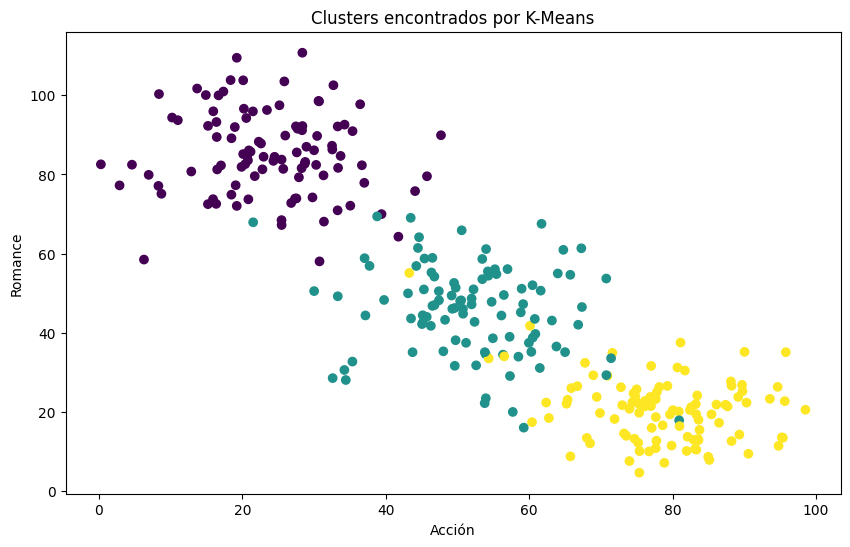

In [9]:

plt.figure(figsize=(10,6))

plt.scatter(
    movies_df['accion'],
    movies_df['romance'],
    c=movies_df['cluster']
)

plt.xlabel('Acción')
plt.ylabel('Romance')
plt.title('Clusters encontrados por K-Means')

plt.show()


## 11. Visualización de centroides

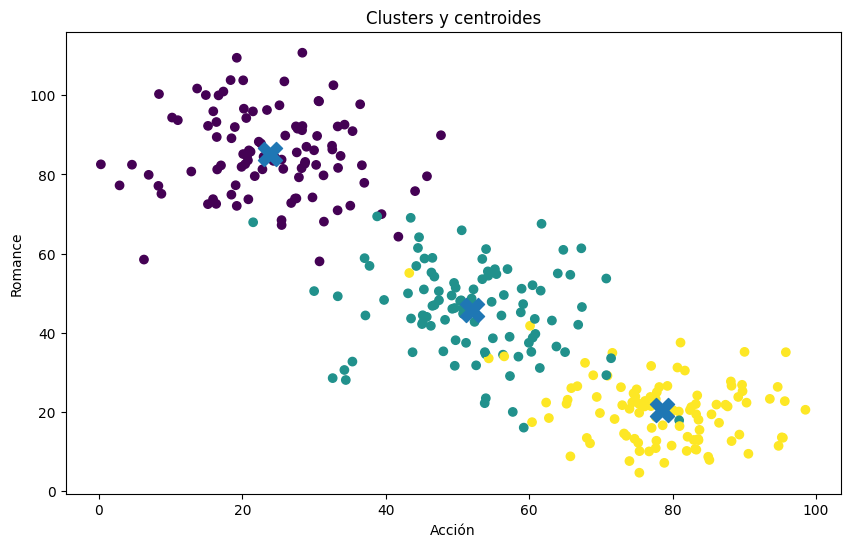

In [10]:

centroides = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

plt.scatter(
    movies_df['accion'],
    movies_df['romance'],
    c=movies_df['cluster']
)

plt.scatter(
    centroides[:,0],
    centroides[:,1],
    s=300,
    marker='X'
)

plt.xlabel('Acción')
plt.ylabel('Romance')
plt.title('Clusters y centroides')

plt.show()


## 12. Método del codo

In [11]:

inercias = []

valores_k = range(1, 11)

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)


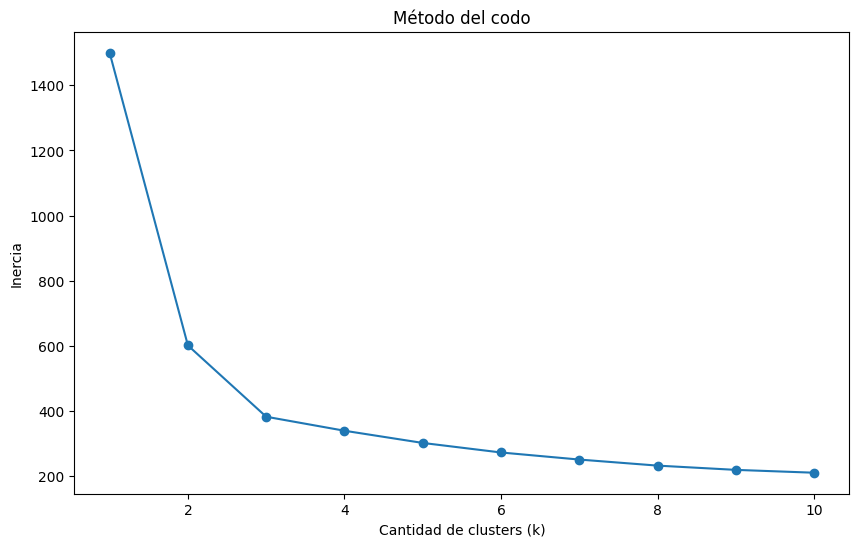

In [12]:

plt.figure(figsize=(10,6))

plt.plot(valores_k, inercias, marker='o')

plt.xlabel('Cantidad de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')

plt.show()


## 13. Silhouette Score

In [13]:

silhouette_scores = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)


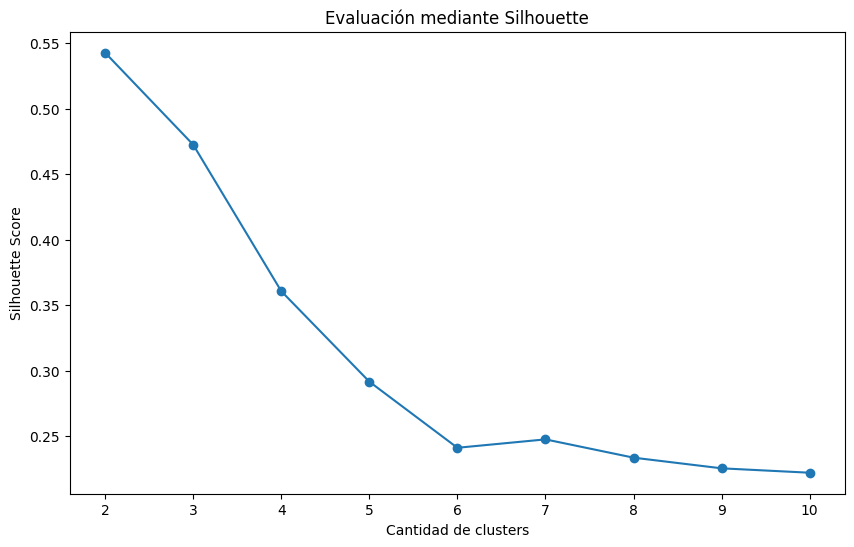

In [14]:

plt.figure(figsize=(10,6))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel('Cantidad de clusters')
plt.ylabel('Silhouette Score')
plt.title('Evaluación mediante Silhouette')

plt.show()


## 14. Fronteras aproximadas de decisión

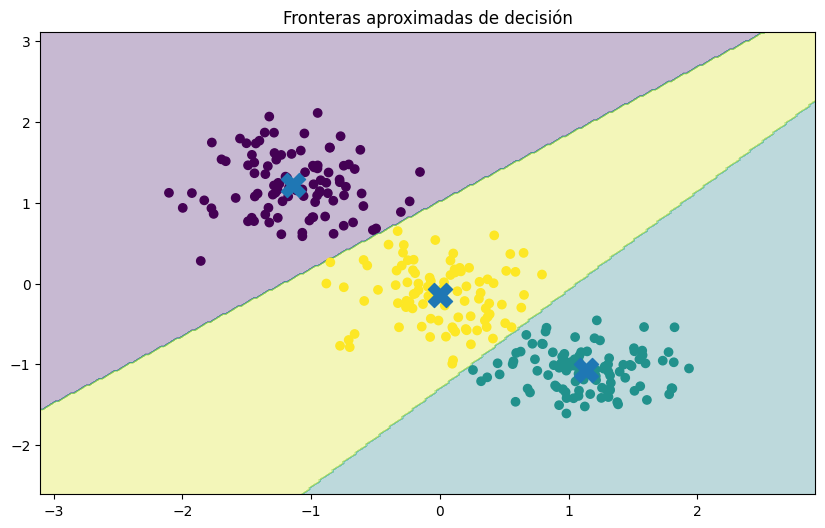

In [15]:

X = movies_df[['accion', 'romance']].values

scaler_2d = StandardScaler()
X_scaled_2d = scaler_2d.fit_transform(X)

modelo_2d = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

modelo_2d.fit(X_scaled_2d)

x_min, x_max = X_scaled_2d[:, 0].min() - 1, X_scaled_2d[:, 0].max() + 1
y_min, y_max = X_scaled_2d[:, 1].min() - 1, X_scaled_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = modelo_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_scaled_2d[:,0],
    X_scaled_2d[:,1],
    c=modelo_2d.labels_
)

plt.scatter(
    modelo_2d.cluster_centers_[:,0],
    modelo_2d.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.title('Fronteras aproximadas de decisión')

plt.show()


## 15. Predicción de nuevos usuarios

In [16]:

nuevo_usuario = pd.DataFrame({
    'accion': [85],
    'romance': [15],
    'scifi': [80],
    'horas_streaming': [28],
    'puntaje_promedio': [8.5]
})

nuevo_usuario_scaled = scaler.transform(nuevo_usuario)

prediccion = kmeans.predict(nuevo_usuario_scaled)

print(prediccion)


[2]


## 16. Interpretación de clusters

In [17]:

movies_df.groupby('cluster').mean()


,accion,romance,scifi,horas_streaming,puntaje_promedio
cluster,,,,,
0,23.846944,85.240939,29.938394,19.143245,7.022283
1,52.015915,45.642219,89.843646,30.289311,9.165493
2,78.547364,20.607134,71.170564,25.070354,7.927508


## 17. Ventajas de K-Means

- Simple.
- Rápido.
- Fácil de interpretar.

## 18. Desventajas de K-Means

- Necesita elegir k.
- Sensible a outliers.
- Sensible a escalas.

## 19. Conclusiones

Aprendimos cómo funciona K-Means, cómo visualizar clusters y cómo realizar predicciones.

## 20. Posibles ejercicios adicionales

1. Agregar más variables.
2. Comparar con DBSCAN.
3. Aplicar PCA.
4. Utilizar datos reales.